# 08 · Mixed-effects robustness

In [1]:
# Trial-level crossed mixed-effects summary: positive gain_beta means the dense/SAE prediction adds signal beyond the surprisal baseline.
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").is_dir() and (p / "results").is_dir())
sys.path.insert(0, str(ROOT / "src"))
from utils import *

P = paths(ROOT)
FIG = P["figures"]
set_style()
pd.set_option("display.precision", 3)

me = pd.read_csv(ROOT / "reports/mixed_effects/mixed_effects_primary.csv")
me["gain_beta"] = me["delta_beta"]
me["gain_beta_ci_low"] = me["delta_beta"] - 1.96 * me["delta_se"]
me["gain_beta_ci_high"] = me["delta_beta"] + 1.96 * me["delta_se"]
me["delta_aic"] = me["aic_baseline"] - me["aic_with_delta"]

In [2]:
# Compact table: darker green/pink cells indicate larger positive gain for that corpus.
table = me.copy()
table["Dataset"] = table["dataset"]
table["State"] = table["state"]
table["Representation"] = table["representation_label"]
table["β gain"] = table["gain_beta"]
table["β 95% CI"] = table.apply(lambda r: f"[{r.gain_beta_ci_low:+.4f}, {r.gain_beta_ci_high:+.4f}]", axis=1)
table["LRT p"] = table["lrt_p"].map(lambda p: "< .001" if p < .001 else f"{p:.3f}")
table["ΔAIC"] = table["delta_aic"]
table = table[["Dataset", "State", "Representation", "hook", "n_trials", "n_participants", "n_items", "β gain", "β 95% CI", "LRT p", "ΔAIC"]]
table.columns = ["Dataset", "State", "Representation", "Hook", "Trials", "Participants", "Items", "β gain", "β 95% CI", "LRT p", "ΔAIC"]
display(focus_table(table.round({"β gain": 4, "ΔAIC": 1}),
                    important=["β gain", "ΔAIC"], signed_columns=["β gain", "ΔAIC"],
                    formats={"β gain": "{:+.4f}", "ΔAIC": "{:.1f}"},
                    caption="Trial-level mixed-effects check: representation gain is model prediction minus baseline prediction."))

Dataset,State,Representation,Hook,Trials,Participants,Items,β gain,β 95% CI,LRT p,ΔAIC
Provo,Before word,Dense state,L01,153566,84,2743,+0.0104,"[+0.0070, +0.0139]",< .001,33.0
Provo,Before word,SAE features,L01,153566,84,2743,+0.0183,"[+0.0149, +0.0217]",< .001,108.0
Provo,After word,Dense state,L01,153566,84,2743,+0.0196,"[+0.0162, +0.0230]",< .001,120.5
Provo,After word,SAE features,L01,153566,84,2743,+0.0251,"[+0.0218, +0.0285]",< .001,207.1
Natural Stories,Before word,Dense state,L08,847310,169,10256,+0.0112,"[+0.0098, +0.0127]",< .001,228.3
Natural Stories,Before word,SAE features,L08,847310,169,10256,+0.0074,"[+0.0060, +0.0089]",< .001,97.9
Natural Stories,After word,Dense state,L08,847310,169,10256,+0.0147,"[+0.0133, +0.0161]",< .001,417.2
Natural Stories,After word,SAE features,L08,847310,169,10256,+0.0104,"[+0.0091, +0.0118]",< .001,211.1


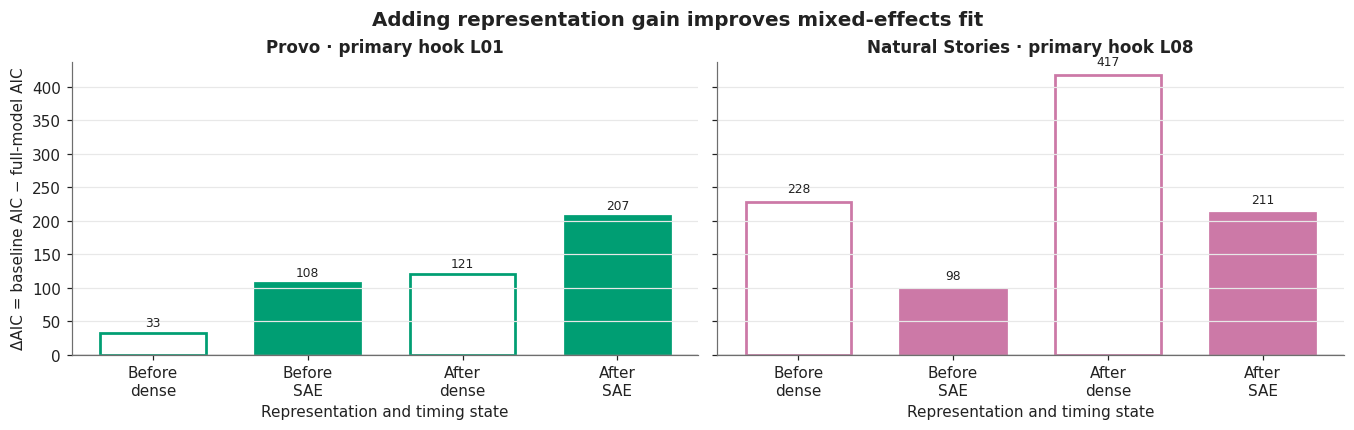

In [3]:
# Complementary figure: model-comparison strength, not another coefficient table.
fig, axes = plt.subplots(1, 2, figsize=(12.2, 3.8), layout="constrained", sharey=True)
order = [("prefix", "dense"), ("prefix", "sae"), ("post", "dense"), ("post", "sae")]
labels = ["Before\ndense", "Before\nSAE", "After\ndense", "After\nSAE"]

for ax, corpus in zip(axes, CORPORA):
    g = me[me.corpus == corpus]
    color = CORPUS_COLORS[corpus]
    for i, (kind, rep) in enumerate(order):
        r = g[(g.kind == kind) & (g.representation == rep)].iloc[0]
        ax.bar(i, r.delta_aic, color=color if rep == "sae" else "white",
               edgecolor=color, linewidth=1.8, width=0.68)
        ax.text(i, r.delta_aic + max(g.delta_aic) * 0.025, f"{r.delta_aic:.0f}",
                ha="center", va="bottom", fontsize=8, color=INK)
    ax.axhline(0, color=MUTED, lw=0.9)
    ax.set_xticks(range(len(order)), labels)
    ax.set_title(f"{CORPUS_LABELS[corpus].split(' ·')[0]} · primary hook {g.hook.iloc[0]}")
    ax.grid(axis="y", color=GRID)
    ax.set_xlabel("Representation and timing state")
axes[0].set_ylabel("ΔAIC = baseline AIC − full-model AIC")
fig.suptitle("Adding representation gain improves mixed-effects fit", fontsize=13, fontweight="bold")
save_figure(fig, FIG, "08_mixed_effects_delta_aic")
plt.show()